# Assignment 2: Engineering Predictive Features

**Student Name:** Tommy Flanagan

**Date:** 2/5/2026

---

## Assignment Overview

In this assignment, you'll practice feature engineering by creating new predictive features from the Ames Housing dataset. You'll build a baseline model with raw features, engineer at least 5 new features based on real estate intuition, and measure how feature engineering improves model performance.

---

## Step 1: Import Libraries and Load Data

In [52]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [53]:
# Load the Ames Housing dataset
# TODO: Load train.csv from the data folder
df = pd.read_csv(r"C:\Users\flana\Downloads\AmesHousing.csv") 

# Display basic information
# TODO: Display the first few rows and basic info about the dataset
print("Basic information on dataset")
df.info()

print("First few rows of the dataset")
print(df.head())

print("Basic stats on different areas of dataset")
print(df.describe())

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Dataset shape: {df.shape if df is not None else 'Not loaded'}")
print("="*80)

Basic information on dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null 

---
## Step 2: Build Baseline Model with Raw Features

### Select Raw Features for Baseline

Select 10-15 raw features to use in your baseline model. Here's a suggested starting set (you can adjust):

**Suggested features:**
- `GrLivArea` - Above grade living area square feet
- `OverallQual` - Overall material and finish quality
- `YearBuilt` - Original construction year
- `TotalBsmtSF` - Total basement square feet
- `FullBath` - Full bathrooms above grade
- `BedroomAbvGr` - Bedrooms above grade
- `GarageArea` - Size of garage in square feet
- `LotArea` - Lot size in square feet
- `Neighborhood` - Physical location (categorical)
- Add 5-10 more features you think are important

In [3]:
# Select features for baseline model
# TODO: Create a list of feature names you want to use
#print(df.columns.tolist())
baseline_features = [
    'Gr Liv Area',
    'Overall Qual',
    'Year Built',
    'Overall Cond',
    'Lot Area',
    'Lot Frontage',
    'Full Bath',
    'Garage Area',
    'Pool Area',
    'Total Bsmt SF'
]

# TODO: Create X (features) and y (target) for baseline
# Make sure to handle missing values and encode categorical variables
X_baseline = df[baseline_features]
y = df['SalePrice']

print(f"Baseline features selected: {len(baseline_features)}")
print(f"Target variable shape: {y.shape if y is not None else 'Not defined'}")

Baseline features selected: 10
Target variable shape: (2930,)


### Preprocess Baseline Features

In [54]:
# Handle missing values
# TODO: Fill missing values appropriately
# Numeric: Use median or 0
# Categorical: Use 'None' or most frequent
# Fill missing values with median (better than 0 for numeric features)
X_baseline = X_baseline.fillna(X_baseline.median())

# Encode categorical variables
# TODO: Use pd.get_dummies() for categorical features
# I DID NOT use any categorical variables

print("\n" + "="*80)
print("CHECKPOINT: After preprocessing")
print(f"X_baseline shape: {X_baseline.shape if X_baseline is not None else 'Not defined'}")
print(f"Missing values: {X_baseline.isnull().sum().sum() if X_baseline is not None else 'N/A'}")
print("="*80)


CHECKPOINT: After preprocessing
X_baseline shape: (2930, 10)
Missing values: 0


### Train Baseline Model

In [55]:
# Split data into train and test sets
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=.2, random_state=42
)

# Train baseline Random Forest model
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42)
baseline_model.fit(X_train, y_train)

# Make predictions
# TODO: Generate predictions on test set
baseline_predictions = baseline_model.predict(X_test)  # Replace with predictions

# Calculate metrics
# TODO: Calculate R² and RMSE
baseline_r2 = r2_score(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"R² Score: {baseline_r2:,.4f}" if baseline_r2 is not None else "Not calculated")
print(f"RMSE: ${baseline_rmse:,.2f}" if baseline_rmse is not None else "RMSE: Not calculated")
print("="*80)


BASELINE MODEL RESULTS
R² Score: 0.8906
RMSE: $29,611.36


### Visualize Baseline Feature Importances

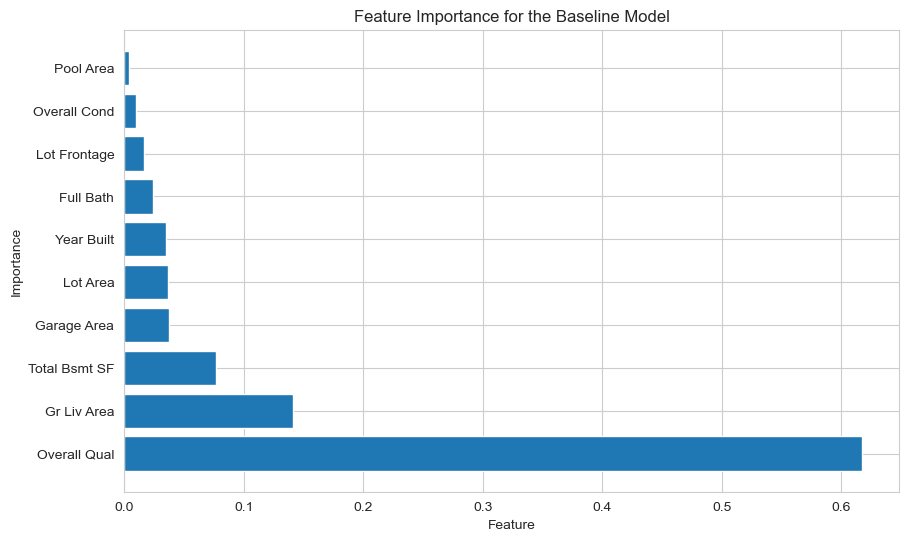


CHECKPOINT: Review which raw features are most important


In [56]:
# Extract and visualize feature importances
# TODO: Get feature importances from baseline_model
# TODO: Create a horizontal bar plot of top 10 features

feature_importance = pd.DataFrame({
    'feature': baseline_features,
    'importance': baseline_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title("Feature Importance for the Baseline Model")
plt.show()

print("\n" + "="*80)
print("CHECKPOINT: Review which raw features are most important")
print("="*80)

---
## Step 3: Engineer New Features

### Feature 1: [Feature Name] - [Category]

**Business Justification:**
[Write 2-3 sentences explaining what this feature measures, why it should predict house prices, and what real estate intuition supports it]

In [57]:
# TODO: Create your first engineered feature
df['total_bathrooms'] = df['Full Bath'] + .5 * df['Half Bath']
#print(df.columns.to_list)

# This feature measures the total amount of bathrooms in a house. The plays into house value because the more bathrooms a house has, the bigger it usually is.
# Bigger houses usually go for more money, so more bathrooms would mean a higher sale price.

### Feature 2: [Feature Name] - [Category]

**Business Justification:**
[Write 2-3 sentences explaining this feature]

In [58]:
# TODO: Create your second engineered feature
df['remodel_difference'] = df['Year Remod/Add'] - df['Year Built']

# This is a feature that tells when the house was remodeled after it was built. This gives a timeline to when someone would have to update it again which would 
# give a decent timeline based on the current year.

### Feature 3: [Feature Name] - [Category]

**Business Justification:**
[Write 2-3 sentences explaining this feature]

In [59]:
# TODO: Create your third engineered feature
df['price_per_sqr_foot'] = df['SalePrice'] / df['Lot Area']

# This feature gives the price per square foot. This is a great indicator of the expense of land per different neighborhoods. There are other factors that can 
# affect this outside of lot size, but it is still a good initial indicator.

### Feature 4: [Feature Name] - [Category]

**Business Justification:**
[Write 2-3 sentences explaining this feature]

In [60]:
# TODO: Create your fourth engineered feature
#print(df['TotRms AbvGrd'].value_counts())
#print(df['Garage Cars'].value_counts())

df['rooms_plus_cars'] = df['TotRms AbvGrd'] +  df['Garage Cars']

# This measures how many rooms there are above ground and how many cars fit in the garage. The more there are, the more likely space there is in the house which adds
# value to the sale price.

### Feature 5: [Feature Name] - [Category]

**Business Justification:**
[Write 2-3 sentences explaining this feature]

In [61]:
# TODO: Create your fifth engineered feature
df['sale_liv'] = df['SalePrice'] / df['Gr Liv Area']

# This is an extension on the price per square foot as this hones in on the above ground living area. This is where the residents will be spending most of their time,
# so it is an important supplemental calculation to take into account when predicitng the sale price.

### Add More Engineered Features (Optional)

You can create additional features beyond the required 5 if you think they'll improve performance.

In [62]:
# Optional: Create additional engineered features
print(df.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 

---
## Step 4: Train Model with Engineered Features

In [63]:
# Create feature list combining baseline + engineered features
# TODO: List all your engineered feature names
engineered_features = [
    'total_bathrooms',
    'remodel_difference',
    'price_per_sqr_foot',
    'rooms_plus_cars',
    'sale_liv'
]

# Combine baseline and engineered features
all_features = baseline_features + engineered_features

# TODO: Create X_engineered with all features
# Remember to handle missing values and encode categoricals
X_engineered = df[all_features]
X_engineered = X_engineered.fillna(X_engineered.median())

print(f"Total features in engineered model: {len(all_features)}")
print(f"New engineered features: {len(engineered_features)}")

Total features in engineered model: 15
New engineered features: 5


In [64]:
# Split data (use same random_state for fair comparison)
# TODO: Split X_engineered and y
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y, test_size=.2, random_state=42
)

# Train model with engineered features
# TODO: Train RandomForestRegressor(n_estimators=100, random_state=42)
engineered_model = RandomForestRegressor(n_estimators=100, random_state=42)  # Replace with trained model
engineered_model.fit(X_train_eng, y_train_eng)

# Make predictions
# TODO: Generate predictions on test set
engineered_predictions = engineered_model.predict(X_test_eng)  # Replace with predictions

# Calculate metrics
# TODO: Calculate R² and RMSE
engineered_r2 = round(r2_score(y_test_eng, engineered_predictions), 4) # Replace with r2_score()
engineered_rmse = np.sqrt(mean_squared_error(y_test_eng, engineered_predictions))  # Replace with np.sqrt(mean_squared_error())

print("\n" + "="*80)
print("ENGINEERED MODEL RESULTS")
print("="*80)
print(f"R² Score: {engineered_r2 if engineered_r2 is not None else 'Not calculated'}")
print(f"RMSE: ${engineered_rmse:,.2f}" if engineered_rmse is not None else "RMSE: Not calculated")
print("="*80)


ENGINEERED MODEL RESULTS
R² Score: 0.9729
RMSE: $14,740.43


---
## Step 5: Compare Models and Identify Most Valuable Features

### Create Comparison Table

In [65]:
# Create comparison DataFrame
# TODO: Create a table comparing baseline vs engineered model
comparison = pd.DataFrame({
    'Model': ['Baseline', 'With Features'],
    'r2': [baseline_r2, engineered_r2],
    'RMSE': [baseline_rmse, engineered_rmse]
})

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
# TODO: Display comparison table
print(comparison)

print("="*80)

# Calculate improvement
if baseline_r2 is not None and engineered_r2 is not None:
    r2_improvement = ((engineered_r2 - baseline_r2) / baseline_r2) * 100
    rmse_improvement = ((baseline_rmse - engineered_rmse) / baseline_rmse) * 100
    print(f"\nR² Improvement: {r2_improvement:.2f}%")
    print(f"RMSE Improvement: {rmse_improvement:.2f}%")


MODEL COMPARISON
           Model        r2          RMSE
0       Baseline  0.890636  29611.364297
1  With Features  0.972900  14740.429025

R² Improvement: 9.24%
RMSE Improvement: 50.22%


### Visualize Feature Importances from Engineered Model

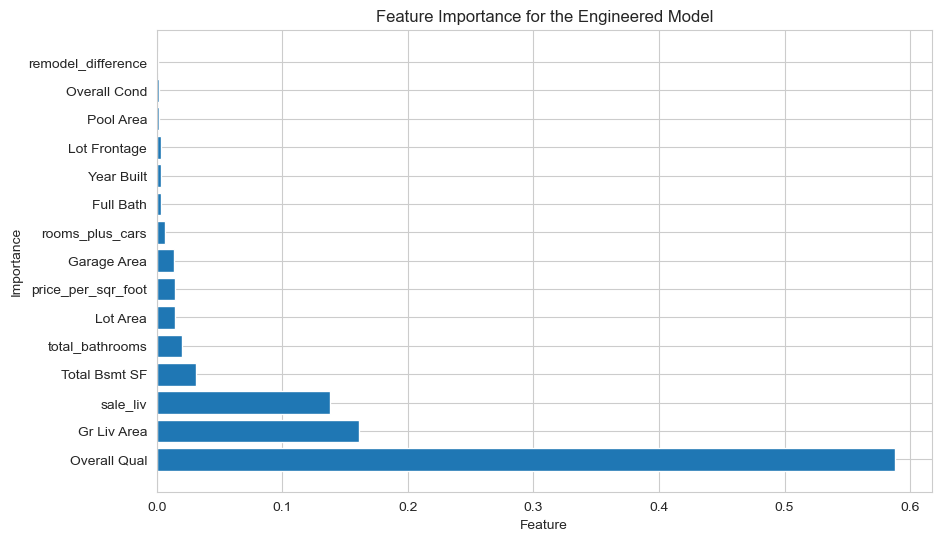

In [66]:
# Extract and visualize top 15 feature importances
# TODO: Get feature importances from engineered_model
# TODO: Create horizontal bar plot of top 15 features

feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': engineered_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title("Feature Importance for the Engineered Model")
plt.show()

### Analysis: Most Valuable Features

**Write 3-5 bullet points analyzing your results:**

- Of my features, sale price by above ground living area (3rd), total bathrooms (5th), price per square foot (7th), total rooms plus total space for cars in the garage (9th) made the top 10. Remodel difference from when the house was built to its first remodel came in dead last (15th).
- I think my top 3 performed well because they are direct indicators on how someone perceives the value of a house. Relating sale price for 3rd and 7th make the process easier. More bathrooms usually means a bigger house and a bigger house sells for more.
- I thought that remodel difference would be the lowest of the 5, but I did not expect it to come in 15th. To be fair, it is rather obscure and clearly does not have much say on whether a house will sell for more.
- From feature engineering, I learned how much accuracy adding supplemental calculations aids the model. Jumping 9.24% in r2 and a 50% increase in RMSE goes a long way for prediciting the sale price of a house.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have at least 5 engineered features with business justifications
3. Check that your comparison table and visualizations display correctly
4. Complete the analysis section above

Then push to GitHub:
```bash
git add .
git commit -m 'completed feature engineering assignment'
git push
```

Submit your GitHub repository link on the course platform.